## analysing enso characteristics and its changes zecmip experiments

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import os
import xarray as xr
import xcdat as xc
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm as BM
import pandas as pd
import matplotlib as mpl
import matplotlib.ticker as mticker
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [3]:
import cmocean

In [4]:
from scipy import stats

In [ ]:
mpl.rcParams['font.family'] = 'Droid Sans'
mpl.rcParams['font.size'] = 14
# Edit axes parameters
mpl.rcParams['axes.linewidth'] = 1.5
# Tick properties
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.direction'] = 'out'

In [6]:
def plot_decorator():
    plt.minorticks_on()
    plt.tick_params(which='minor', axis='x', bottom=False)
    plt.grid(alpha=0.05)

In [7]:
import matplotlib as mpl
from matplotlib.colors import BoundaryNorm as BM
from matplotlib.colors import LogNorm as LM
import matplotlib.patches as mpatches

In [8]:
def plot_background(ax):
    ax.add_feature(cfeature.COASTLINE, alpha=0.9, lw=1.1)
    # ax.set_global()
    # ax.add_feature(cfeature.LAND, color='lightgray')
    # ax.add_feature(cfeature.OCEAN, color='lightgray')
    gl = ax.gridlines(draw_labels=True,
                      linewidth=1, color='gray', alpha=0.01, linestyle='--')
    gl.top_labels = False
    # gl.left_labels = False
    # gl.bottom_labels = False
    gl.right_labels = False
    gl.xlines = False
    # gl.xlocator = mticker.FixedLocator([-180, -45, 0, 45, 180])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'color': 'k'}
    gl.ylabel_style = {'size': 10, 'color': 'k'}
    return ax


def plot_maps(x, y, z, titles, labels, cmap, levels, cbar_label = 'Precip', pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', nrows=1, ncols=3, figsize=(12,4), land_mask_list = [0], add_patch=False, add_patch_extra=False, cbar_orientation='vertical', hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160)):
    fig, axarr = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=True, subplot_kw={'projection':proj})
    
    axlist = axarr.flatten()
    
    for ax in axlist:
        plot_background(ax)
    
    for i in range(len(z)):
        axlist[i].contourf(x, y, z[i], cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
        axlist[i].set_title(titles[i])
        if draw_winds:
            axlist[i].quiver(x[::3, ::3], y[::3, ::3], u_wnd[i].to_numpy()[::3, ::3], v_wnd[i].to_numpy()[::3, ::3], scale=wind_scale, color='k', transform=ccrs.PlateCarree())
        if draw_contour:
            axlist[i].contour(x, y, contour_data[i], cmap = None, levels=contour_levels, colors=contour_colors, transform = ccrs.PlateCarree(central_longitude=0))
        if i in land_mask_list:
            axlist[i].add_feature(cfeature.LAND, color = 'k', zorder=1)
        if pval != []:
            if hatch_type == 'insig':
                pval_plot = np.ma.masked_less_equal(pval[i], 0.05)
            elif hatch_type == 'sig':
                pval_plot = np.ma.masked_greater(pval[i], 0.05)
            axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='////', transform = ccrs.PlateCarree(central_longitude=0))
        axlist[i].set_title(titles[i], fontdict={'fontsize':12})
        axlist[i].text(0.1, 1.05, labels[i], size=16, fontweight='bold', transform=axlist[i].transAxes)
        if add_patch:
            # axlist[i].add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, 60], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, -80], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
        if add_patch_extra:
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
                    
    norm = BM(levels, 256, extend='both')
    fig.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap=cmap), ax = axlist, \
                orientation = cbar_orientation, shrink=0.8, aspect = 45, pad = 0.05, label = cbar_label)

In [9]:
from functions import preproc_funcs as funcs

### importing data

In [10]:
models_zec = [
    'ACCESS-ESM1-5',
    'CanESM5',
    'CESM2',
    'GFDL-ESM4',
    # 'GISS-E2-1-G-CC', # 1pctCO2 not present in local directories
    'MIROC-ES2L',
    'MPI-ESM1-2-LR',
    'NorESM2-LM',
    'UKESM1-0-LL',
]

In [11]:
models_zec_warming_levels = [
    'ACCESS-ESM1-5',
    'MIROC-ES2L',
    'UKESM1-0-LL',
]

In [12]:
list_pic = []

for m in range(len(models_zec)):
    ds = xr.open_dataset(f'/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/zecmip/{models_zec[m]}_pic_tas.nc').tas
    list_pic.append(funcs.calc_anom(ds, ds.isel(time = slice(0, 350))))

pic_dat = dict(zip(list(models_zec), list_pic))

In [13]:
list_1pctco2 = []
list_brch1000 = []
for m in range(len(models_zec)):
    base = xr.open_dataset(f'/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/zecmip/{models_zec[m]}_pic_tas.nc').tas
    ds = xr.open_dataset(f'/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/zecmip/{models_zec[m]}_1pctco2_tas.nc').tas.load()
    list_1pctco2.append(funcs.calc_anom(ds, base.isel(time = slice(0, 350))))
    ds1 = xr.open_dataset(f'/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/zecmip/{models_zec[m]}_brch1000_tas.nc').tas.load()
    list_brch1000.append(funcs.calc_anom(ds1, base.isel(time = slice(0, 350))))

trans_dat = dict(zip(list(models_zec), list_1pctco2))
stable1000_dat = dict(zip(list(models_zec), list_brch1000))

In [14]:
list_brch750 = []
list_brch2000 = []
for m in range(len(models_zec_warming_levels)):
    base = xr.open_dataset(f'/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/zecmip/{models_zec_warming_levels[m]}_pic_tas.nc').tas
    # ds = xr.open_dataset(f'/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/zecmip/{models_zec_warming_levels[m]}_1pctco2_tas.nc').tas
    # list_1pctco2.append(funcs.calc_anom(ds, ds.isel(time = slice(0, 50))))
    ds1 = xr.open_dataset(f'/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/zecmip/{models_zec_warming_levels[m]}_brch750_tas.nc').tas.load()
    list_brch750.append(funcs.calc_anom(ds1, base.isel(time = slice(0, 350))))
    ds2 = xr.open_dataset(f'/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/zecmip/{models_zec_warming_levels[m]}_brch2000_tas.nc').tas.load()
    list_brch2000.append(funcs.calc_anom(ds2, base.isel(time = slice(0, 350))))


stable750_dat = dict(zip(list(models_zec_warming_levels), list_brch750))
stable2000_dat = dict(zip(list(models_zec_warming_levels), list_brch2000))

In [15]:
list_brch750[2]

<xarray.DataArray 'tas' (model: 1, time: 102, lat: 120, lon: 240)>
array([[[[ 2.8581848 ,  2.8530426 ,  2.8430023 , ...,  2.8743744 ,
           2.8639984 ,  2.8603973 ],
         [ 3.444458  ,  3.4199219 ,  3.3990479 , ...,  3.4906921 ,
           3.4796448 ,  3.4662476 ],
         [ 3.960312  ,  3.9293518 ,  3.9009705 , ...,  4.0090027 ,
           3.999298  ,  3.9858093 ],
         ...,
         [-0.54922485, -0.5675049 , -0.5779877 , ..., -0.5161438 ,
          -0.528183  , -0.5329895 ],
         [-0.35517883, -0.3664856 , -0.37553406, ..., -0.3338623 ,
          -0.34077454, -0.3455963 ],
         [-0.34509277, -0.33927917, -0.32948303, ..., -0.34934998,
          -0.34983826, -0.3476715 ]],

        [[ 2.7081604 ,  2.7077332 ,  2.7096252 , ...,  2.708786  ,
           2.7093353 ,  2.7093506 ],
         [ 2.193924  ,  2.2030334 ,  2.2094116 , ...,  2.1782227 ,
           2.1821442 ,  2.1858368 ],
         [ 1.888443  ,  1.900238  ,  1.9083862 , ...,  1.8693695 ,
           1.8770294 ,  1.879242  ],
...
         [10.68692   , 10.756241  , 10.824142  , ..., 10.455292  ,
          10.535065  , 10.612717  ],
         [10.625427  , 10.666443  , 10.708618  , ..., 10.485825  ,
          10.53302   , 10.581512  ],
         [10.690765  , 10.69725   , 10.708023  , ..., 10.666153  ,
          10.673737  , 10.6844635 ]],

        [[ 0.3577881 ,  0.35827637,  0.35910034, ...,  0.35585022,
           0.35598755,  0.35707092],
         [ 0.61509705,  0.6215973 ,  0.6257782 , ...,  0.57748413,
           0.585968  ,  0.60292053],
         [ 0.67141724,  0.67962646,  0.684906  , ...,  0.62112427,
           0.64328   ,  0.65911865],
         ...,
         [15.1026    , 15.1349945 , 15.162918  , ..., 15.047913  ,
          15.05838   , 15.074142  ],
         [15.251068  , 15.266907  , 15.278564  , ..., 15.196671  ,
          15.217987  , 15.233673  ],
         [15.229187  , 15.232529  , 15.237442  , ..., 15.216171  ,
          15.221313  , 15.225876  ]]]], dtype=float32)
Coordinates:
    height              (time) float64 1.5 1.5 1.5 1.5 1.5 ... 1.5 1.5 1.5 1.5
  * time                (time) object 1902-06-01 00:00:00 ... 2003-06-01 00:0...
    latitude_longitude  (time) float64 nan nan nan nan nan ... nan nan nan nan
  * lon                 (lon) float64 0.0 1.5 3.0 4.5 ... 355.5 357.0 358.5
  * lat                 (lat) float64 -89.25 -87.75 -86.25 ... 86.25 87.75 89.25
  * model               (model) object 'UKESM1-0-LL_r1i1p1f'
    month               (time) int64 6 6 6 6 6 6 6 6 6 6 ... 6 6 6 6 6 6 6 6 6 6

In [16]:
weights = np.cos(np.deg2rad(trans_dat[models_zec[0]].lat))
weights

<xarray.DataArray 'lat' (lat: 120)>
array([0.0130896 , 0.03925982, 0.06540313, 0.09150162, 0.1175374 ,
       0.14349262, 0.1693495 , 0.19509032, 0.22069744, 0.24615329,
       0.27144045, 0.29654157, 0.32143947, 0.34611706, 0.37055744,
       0.39474386, 0.41865974, 0.44228869, 0.46561452, 0.48862124,
       0.51129309, 0.53361452, 0.55557023, 0.57714519, 0.5983246 ,
       0.61909395, 0.639439  , 0.65934582, 0.67880075, 0.69779046,
       0.71630194, 0.73432251, 0.75183981, 0.76884183, 0.78531693,
       0.80125381, 0.81664156, 0.83146961, 0.84572782, 0.85940641,
       0.87249601, 0.88498764, 0.89687274, 0.90814317, 0.91879121,
       0.92880955, 0.93819134, 0.94693013, 0.95501994, 0.96245524,
       0.96923091, 0.97534232, 0.98078528, 0.98555606, 0.98965139,
       0.99306846, 0.99580493, 0.99785892, 0.99922904, 0.99991433,
       0.99991433, 0.99922904, 0.99785892, 0.99580493, 0.99306846,
       0.98965139, 0.98555606, 0.98078528, 0.97534232, 0.96923091,
       0.96245524, 0.95501994, 0.94693013, 0.93819134, 0.92880955,
       0.91879121, 0.90814317, 0.89687274, 0.88498764, 0.87249601,
       0.85940641, 0.84572782, 0.83146961, 0.81664156, 0.80125381,
       0.78531693, 0.76884183, 0.75183981, 0.73432251, 0.71630194,
       0.69779046, 0.67880075, 0.65934582, 0.639439  , 0.61909395,
       0.5983246 , 0.57714519, 0.55557023, 0.53361452, 0.51129309,
       0.48862124, 0.46561452, 0.44228869, 0.41865974, 0.39474386,
       0.37055744, 0.34611706, 0.32143947, 0.29654157, 0.27144045,
       0.24615329, 0.22069744, 0.19509032, 0.1693495 , 0.14349262,
       0.1175374 , 0.09150162, 0.06540313, 0.03925982, 0.0130896 ])
Coordinates:
  * lat      (lat) float64 -89.25 -87.75 -86.25 -84.75 ... 86.25 87.75 89.25
Attributes:
    bounds:         lat_bounds
    standard_name:  latitude
    units:          degrees_north

In [17]:

import seaborn as sns

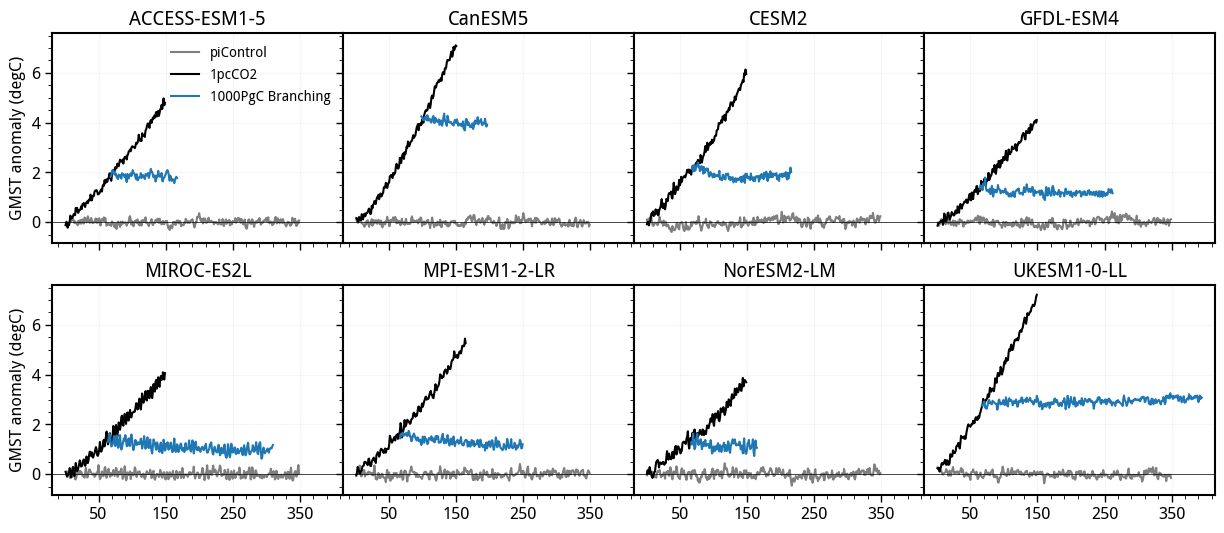

In [58]:
fig, axarr = plt.subplots(nrows=2, ncols=4, figsize=(15,6), constrained_layout=True, sharex=True, sharey=True)
axlist = axarr.flatten()
for i in range(len(axlist)):
    xdata0 = pic_dat[models_zec[i]].time.dt.year
    axlist[i].plot((xdata0 - xdata0[0])[1:350], pic_dat[models_zec[i]].weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, 350), model=0), color='tab:gray', label='piControl')
    xdata = pic_dat[models_zec[i]].time.dt.year
    #
    xdata0 = trans_dat[models_zec[i]].time.dt.year
    axlist[i].plot((xdata0 - xdata0[0])[1:-1], trans_dat[models_zec[i]].weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0), color='k', label='1pcCO2')
    xdata = stable1000_dat[models_zec[i]].time.dt.year
    axlist[i].plot((xdata - xdata0[0])[1:-1], stable1000_dat[models_zec[i]].weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0), color='tab:blue', ls='-', label='1000PgC Branching')
    axlist[i].set_xticks(np.arange(50, 450, 100))
    # axlist[i].set_yticklabels([])
    axlist[i].axhline(0.0, color='k', ls='-', lw=0.5)
    axlist[i].grid(alpha=0.1)
    # axlist[i].set_title(models_zec[i] + f' (n = {len(trans_dat[models_zec[i]].model)})', fontsize=14)
    axlist[i].set_title(models_zec[i], fontsize=14)

axlist[0].set_ylabel('GMST anomaly (degC)')
axlist[4].set_ylabel('GMST anomaly (degC)')
axlist[0].legend(frameon=False, loc='upper right', fontsize=10)

plt.subplots_adjust(wspace=0.0, hspace=0.2)
plt.minorticks_on()
# sns.despine()

In [19]:
zec_values_temporal = np.empty((len(models_zec), 350))
zec_values_temporal[:] = np.nan
for i in range(len(axlist)):
    branching_time = int(stable1000_dat[models_zec[i]].time[0].dt.year)
    if branching_time > 100 and branching_time < 1000:
        start_time = '0'+str(branching_time - 15)
        end_time = '0'+str(branching_time + 15)
    elif branching_time < 100:
        start_time = '00'+str(branching_time - 15)
        end_time = '00'+str(branching_time + 15)
    else:
        start_time = str(branching_time - 15)
        end_time = str(branching_time + 15)
    base = trans_dat[models_zec[i]].sel(time = slice(start_time, end_time)).weighted(weights).mean(('time', 'lat', 'lon')).isel(model=0)
    xdata0 = trans_dat[models_zec[i]].time.dt.year
    xdata = stable1000_dat[models_zec[i]].time.dt.year
    zec_values_temporal[i, 0:len(xdata)-2] = stable1000_dat[models_zec[i]].weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0) - base
    # plt.plot((xdata - xdata0[i])[1:-1], zec_values_temporal, color='k', ls='-', label='1000PgC Branching', alpha=0.2)
    # # plt.set_xticks(np.arange(50, 450, 100))
    # # plt.set_yticklabels([])
    # # plt.axhline(0.0, color='k', ls='-', lw=0.5)
    # plt.grid(alpha=0.1)
    # # plt.set_title(models_zec[i] + f' (n = {len(trans_dat[models_zec[i]].model)})', fontsize=14)
    # plt.set_title(models_zec[i], fontsize=14)

# axlist[0].set_ylabel('Temperature anomaly (degC)')
# axlist[4].set_ylabel('Temperature anomaly (degC)')
# axlist[0].legend(frameon=False, loc='upper right', fontsize=10)

# plt.subplots_adjust(wspace=0.0, hspace=0.2)
# plt.minorticks_on()
# sns.despine()

Text(0.5, 1.0, 'brch-1000PgC ZEC')

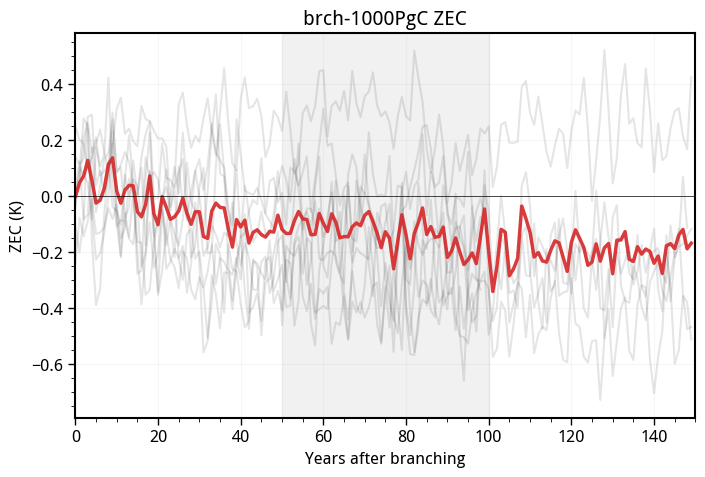

In [20]:
plt.figure(figsize=(8, 5))
for i in range(len(models_zec)):
    plt.plot(zec_values_temporal[i][:150], color='k', alpha=0.1)
plt.plot(np.nanmean(zec_values_temporal, axis=0)[:150], color='tab:red', alpha=0.9, lw=2.5)
# plt.set_yticklabels([])
plt.axhline(0.0, color='k', ls='-', lw=0.5)
plt.grid(alpha=0.1)
plt.minorticks_on()
plt.xlabel('Years after branching')
plt.ylabel('ZEC (K)')
plt.xlim(0, 150)
# plt.axvspan(10, 40, color='tab:blue', alpha=0.1)
# plt.axvspan(35, 65, color='tab:green', alpha=0.1)
# plt.axvspan(75, 105, color='tab:purple', alpha=0.1)
# plt.axvspan(105, 135, color='tab:red', alpha=0.1)
plt.axvspan(50, 100, color='tab:gray', alpha=0.1)
plt.title('brch-1000PgC ZEC')

In [21]:
zec_changes = []
# zec50_changes = []
# zec90_changes = []
# zec120_changes = []


for m in range(len(models_zec)):
    branching_time = int(stable1000_dat[models_zec[m]].time[0].dt.year)
    if branching_time > 100 and branching_time < 1000:
        start_time = '0'+str(branching_time - 15)
        end_time = '0'+str(branching_time + 15)
    elif branching_time < 100:
        start_time = '00'+str(branching_time - 15)
        end_time = '00'+str(branching_time + 15)
    else:
        start_time = str(branching_time - 15)
        end_time = str(branching_time + 15)
    base = trans_dat[models_zec[m]].sel(time = slice(start_time, end_time)).mean(('time', 'model'))

    # post25 = stable1000_dat[models_zec[m]].isel(time = slice(10, 40)).mean(('time', 'model'))
    # post50 = stable1000_dat[models_zec[m]].isel(time = slice(35, 65)).mean(('time', 'model'))
    # post90 = stable1000_dat[models_zec[m]].isel(time = slice(75, 105)).mean(('time', 'model'))
    # post120 = stable1000_dat[models_zec[m]].isel(time = slice(105, 135)).mean(('time', 'model'))
    post = stable1000_dat[models_zec[m]].isel(time = slice(50, 100)).mean(('time', 'model'))

    # zec25_changes.append((post25 - base))
    # zec50_changes.append((post50 - base))
    # zec90_changes.append((post90 - base))
    # zec120_changes.append((post120 - base))
    zec_changes.append((post - base))
    print(f'Completed {m+1}')

Completed 1
Completed 2
Completed 3
Completed 4
Completed 5
Completed 6
Completed 7
Completed 8


In [22]:
xx, yy = np.meshgrid(zec_changes[0].lon, zec_changes[0].lat)

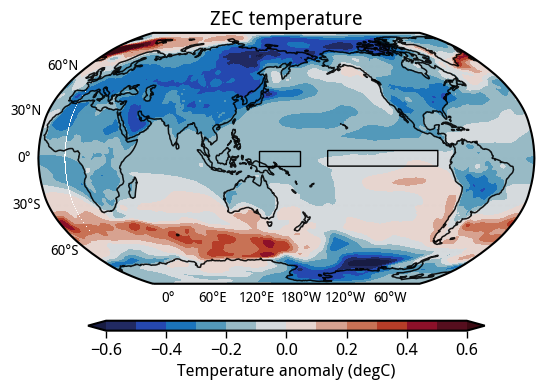

In [23]:
# plot_maps(xx, yy, [xr.concat(zec25_changes, dim=models_zec).mean('concat_dim'), xr.concat(zec50_changes, dim=models_zec).mean('concat_dim'), xr.concat(zec90_changes, dim=models_zec).mean('concat_dim')], titles=['ZEC25', 'ZEC50', 'ZEC90'], labels=['']*3, cmap=cmocean.cm.balance, levels=np.arange(-0.6, 0.7, 0.1), cbar_label = 'Temperature anomaly (degC)', nrows=1, ncols=3, figsize=(12,3), land_mask_list = [], add_patch=True, add_patch_extra=False, cbar_orientation='horizontal', hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160))
ax = plt.axes(projection=ccrs.Robinson(central_longitude=160))
cf = plt.contourf(xx, yy, xr.concat(zec_changes, dim=models_zec).mean('concat_dim'), transform=ccrs.PlateCarree(), cmap=cmocean.cm.balance, levels=np.arange(-0.6, 0.7, 0.1), extend='both')
plot_background(ax)
plt.colorbar(cf, orientation='horizontal', aspect=40, pad=0.1, shrink=0.8, label='Temperature anomaly (degC)')
plt.title('ZEC temperature')
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                    facecolor='none', edgecolor='k',
                                    transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                    facecolor='none', edgecolor='k',
                                    transform=ccrs.PlateCarree()))

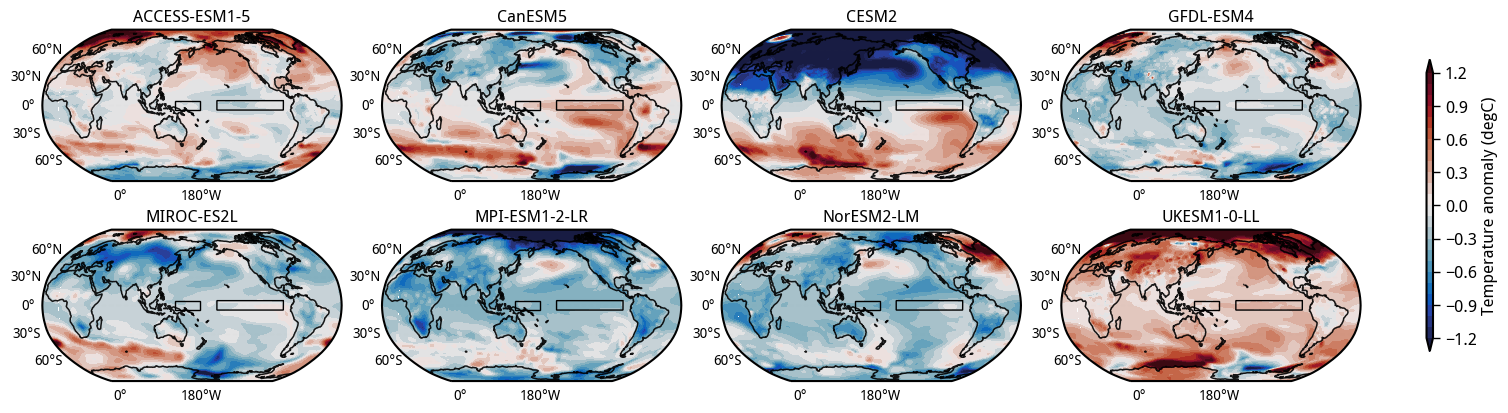

In [24]:
plot_maps(xx, yy, zec_changes, titles=models_zec, labels=['']*8, cmap=cmocean.cm.balance, levels=np.arange(-1.2, 1.3, 0.1), cbar_label = 'Temperature anomaly (degC)', nrows=2, ncols=4, figsize=(15,4), land_mask_list = [], add_patch=True, add_patch_extra=False, cbar_orientation='vertical', hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160))

In [25]:
# zec25_values_global = []
# zec50_values_global = []
# zec90_values_global = []
# zec120_values_global = []
zec_values_global = []

for m in range(len(models_zec)):
    branching_time = int(stable1000_dat[models_zec[m]].time[0].dt.year)
    if branching_time > 100 and branching_time < 1000:
        start_time = '0'+str(branching_time - 15)
        end_time = '0'+str(branching_time + 15)
    elif branching_time < 100:
        start_time = '00'+str(branching_time - 15)
        end_time = '00'+str(branching_time + 15)
    else:
        start_time = str(branching_time - 15)
        end_time = str(branching_time + 15)
    base = trans_dat[models_zec[m]].sel(time = slice(start_time, end_time)).weighted(weights).mean(('lat', 'lon'))

    # post25 = stable1000_dat[models_zec[m]].isel(time = slice(10, 40)).weighted(weights).mean(('lat', 'lon'))
    # post50 = stable1000_dat[models_zec[m]].isel(time = slice(35, 65)).weighted(weights).mean(('lat', 'lon'))
    # post90 = stable1000_dat[models_zec[m]].isel(time = slice(75, 105)).weighted(weights).mean(('lat', 'lon'))
    # post120 = stable1000_dat[models_zec[m]].isel(time = slice(105, 135)).weighted(weights).mean(('lat', 'lon'))
    post = stable1000_dat[models_zec[m]].isel(time = slice(50, 100)).weighted(weights).mean(('lat', 'lon'))

    # zec25_values_global.append((post25.mean('time') - base.mean('time')).to_numpy())
    # zec50_values_global.append((post50.mean('time') - base.mean('time')).to_numpy())
    # zec90_values_global.append((post90.mean('time') - base.mean('time')).to_numpy())
    # zec120_values_global.append((post120.mean('time') - base.mean('time')).to_numpy())
    zec_values_global.append((post.mean('time') - base.mean('time')).to_numpy())
    print(f'Completed {m+1}')

Completed 1
Completed 2
Completed 3
Completed 4
Completed 5
Completed 6
Completed 7
Completed 8


In [26]:
zec_values_global

[array([0.01582383]),
 array([-0.03356626]),
 array([-0.35423461]),
 array([-0.15926963]),
 array([-0.19658171]),
 array([-0.34291393]),
 array([-0.26081308]),
 array([0.26539049])]

(-0.45, 0.45)

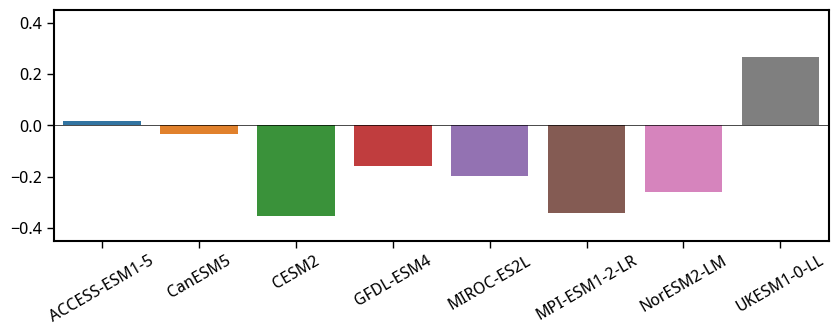

In [27]:
plt.figure(figsize=(10,3))
sns.barplot(zec_values_global)
plt.gca().set_xticklabels(models_zec)
plt.xticks(rotation=30)
plt.axhline(0.0, color='k', lw=0.5)
plt.ylim(-0.45, 0.45)

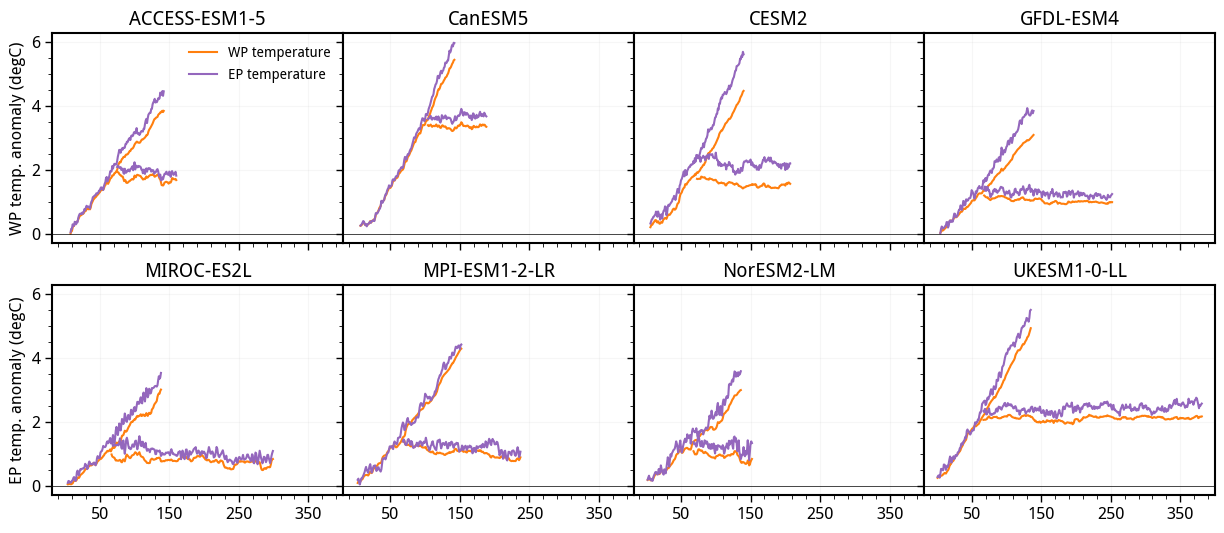

In [ ]:
fig, axarr = plt.subplots(nrows=2, ncols=4, figsize=(15,6), constrained_layout=True, sharex=True, sharey=True)
axlist = axarr.flatten()
for i in range(len(axlist)):
    xdata0 = trans_dat[models_zec[i]].time.dt.year
    axlist[i].plot((xdata0 - xdata0[0])[1:-1], trans_dat[models_zec[i]].sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0).rolling(time=15, center=True).mean('time'), color='tab:orange', label='WP temperature')
    axlist[i].plot((xdata0 - xdata0[0])[1:-1], trans_dat[models_zec[i]].sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0).rolling(time=15, center=True).mean('time'), color='tab:purple', label='EP temperature')
    xdata = stable1000_dat[models_zec[i]].time.dt.year
    axlist[i].plot((xdata - xdata0[0])[1:-1], stable1000_dat[models_zec[i]].sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0).rolling(time=15, center=True).mean('time'), color='tab:orange', ls='-', label='')
    axlist[i].plot((xdata - xdata0[0])[1:-1], stable1000_dat[models_zec[i]].sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0).rolling(time=15, center=True).mean('time'), color='tab:purple', ls='-', label='')
    axlist[i].set_xticks(np.arange(50, 450, 100))
    # axlist[i].set_yticklabels([])
    axlist[i].axhline(0.0, color='k', ls='-', lw=0.5)
    axlist[i].grid(alpha=0.1)
    # axlist[i].set_title(models_zec[i] + f' (n = {len(trans_dat[models_zec[i]].model)})', fontsize=14)
    axlist[i].set_title(models_zec[i], fontsize=14)

axlist[0].set_ylabel('WP temp. anomaly (degC)')
axlist[4].set_ylabel('EP temp. anomaly (degC)')
axlist[0].legend(frameon=False, loc='upper right', fontsize=10)

plt.subplots_adjust(wspace=0.0, hspace=0.2)
plt.minorticks_on()
# plt.ylim(0.5,3.5)
# sns.despine()

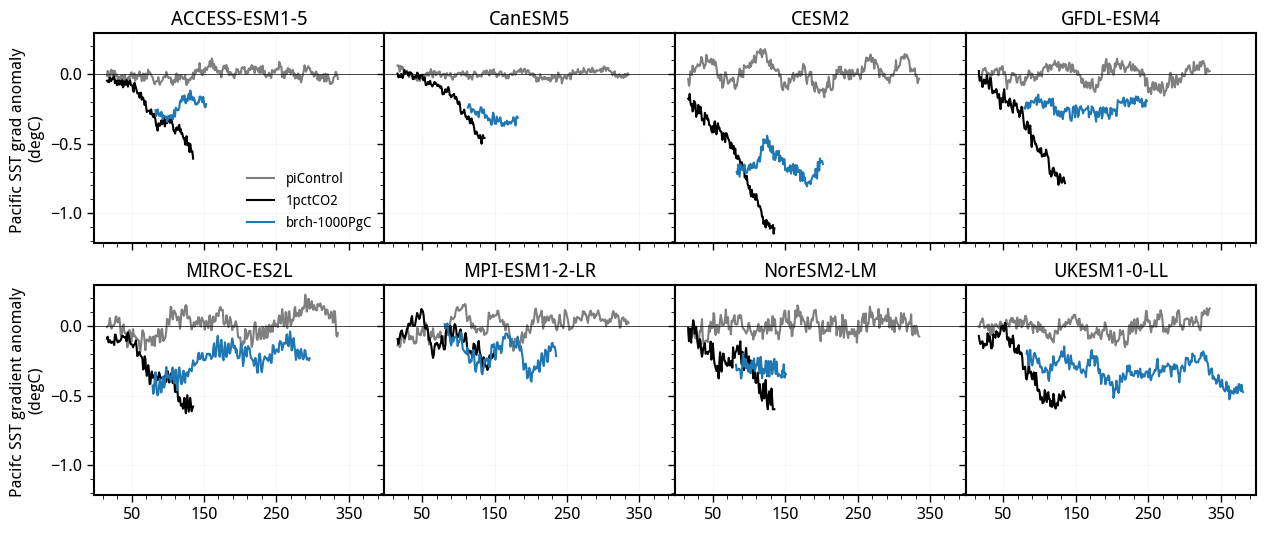

In [59]:
fig, axarr = plt.subplots(nrows=2, ncols=4, figsize=(15,6), constrained_layout=True, sharex=True, sharey=True)
axlist = axarr.flatten()
for i in range(len(axlist)):
    xdata0 = pic_dat[models_zec[i]].time.dt.year
    sst_grad_pic = pic_dat[models_zec[i]].sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0) - pic_dat[models_zec[i]].sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0)
    axlist[i].plot((xdata0 - xdata0[0])[1:350], sst_grad_pic.isel(time = slice(1, 350)).rolling(time=30, center=True).mean('time'), color='tab:gray', label='piControl')
    #
    xdata0 = trans_dat[models_zec[i]].time.dt.year
    sst_grad_trans = trans_dat[models_zec[i]].sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0) - trans_dat[models_zec[i]].sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0)
    axlist[i].plot((xdata0 - xdata0[0])[1:-1], sst_grad_trans.rolling(time=30, center=True).mean('time'), color='k', label='1pctCO2')
    xdata = stable1000_dat[models_zec[i]].time.dt.year
    sst_grad_stable = stable1000_dat[models_zec[i]].sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0) - stable1000_dat[models_zec[i]].sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0)
    axlist[i].plot((xdata - xdata0[0])[1:-1], sst_grad_stable.rolling(time=30, center=True).mean('time'), color='tab:blue', ls='-', label='brch-1000PgC')
    axlist[i].set_xticks(np.arange(50, 450, 100))
    # axlist[i].set_yticklabels([])
    axlist[i].axhline(0.0, color='k', ls='-', lw=0.5)
    axlist[i].grid(alpha=0.1)
    # axlist[i].set_title(models_zec[i] + f' (n = {len(trans_dat[models_zec[i]].model)})', fontsize=14)
    axlist[i].set_title(models_zec[i], fontsize=14)

axlist[0].set_ylabel('Pacific SST grad anomaly \n(degC)')
axlist[4].set_ylabel('Pacifc SST gradient anomaly \n(degC)')
axlist[0].legend(frameon=False, loc='lower right', fontsize=10)

plt.subplots_adjust(wspace=0.0, hspace=0.2)
plt.minorticks_on()
# plt.ylim(0.5,3.5)
# sns.despine()

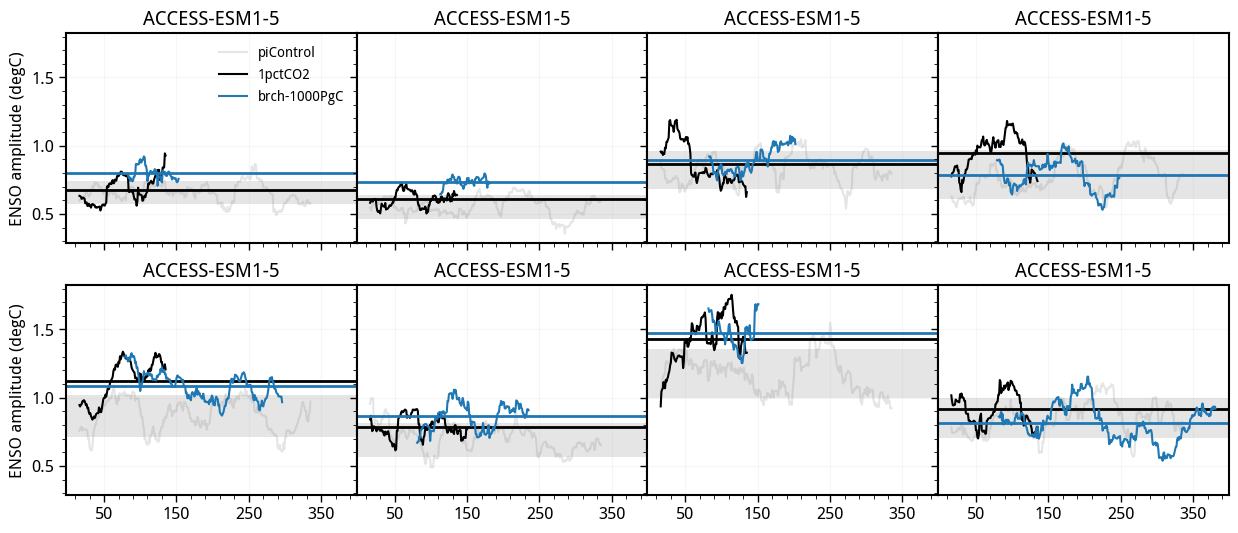

In [56]:
fig, axarr = plt.subplots(nrows=2, ncols=4, figsize=(15,6), constrained_layout=True, sharex=True, sharey=True)
axlist = axarr.flatten()
for i in range(len(axlist)):
    xdata0 = pic_dat[models_zec[i]].time.dt.year
    nino34_pic = funcs.detrend_rolling_window(pic_dat[models_zec[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0)
    axlist[i].plot((xdata0 - xdata0[0])[1:350], nino34_pic.isel(time = slice(1,350)).rolling(time=30, center=True).std('time'), color='tab:gray', alpha=0.2, label='piControl')
    # axlist[i].axhline(nino34_pic.isel(time = slice(1, 350)).rolling(time=30, center=True).std('time').mean('time'), color='tab:gray', lw=2.0)
    axlist[i].axhspan(nino34_pic.isel(time = slice(1, 350)).rolling(time=30, center=True).std('time').quantile(0.1, 'time'), nino34_pic.isel(time = slice(1, 350)).rolling(time=30, center=True).std('time').quantile(0.9, 'time'), color='tab:gray', alpha=0.2, lw=0.0)

    # axlist[i].axhspan(nino34_pic.isel(time = slice(1, -1)).rolling(time=30, center=True).std('time').quantile(0.1, 'time'), nino34_pic.isel(time = slice(1, -1)).rolling(time=30, center=True).std('time').quantile(0.9, 'time'), color='tab:gray', alpha=0.3)
    #
    xdata0 = trans_dat[models_zec[i]].time.dt.year
    nino34_trans = funcs.detrend_rolling_window(trans_dat[models_zec[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0)
    axlist[i].plot((xdata0 - xdata0[0])[1:-1], nino34_trans.rolling(time=30, center=True).std('time'), color='k', label='1pctCO2')
    axlist[i].axhline(nino34_trans.rolling(time=30, center=True).std('time').mean('time'), color='k', lw=2.0)
    #
    xdata = stable1000_dat[models_zec[i]].time.dt.year
    nino34_stable = funcs.detrend_rolling_window(stable1000_dat[models_zec[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0)
    axlist[i].plot((xdata - xdata0[0])[1:-1], nino34_stable.rolling(time=30, center=True).std('time'), color='tab:blue', ls='-', label='brch-1000PgC')
    axlist[i].axhline(nino34_stable.rolling(time=30, center=True).std('time').mean('time'), color='tab:blue', lw=2.0)
    #
    axlist[i].set_xticks(np.arange(50, 450, 100))
    # axlist[i].set_yticklabels([])
    # axlist[i].axhline(0.0, color='k', ls='-', lw=0.5)
    axlist[i].grid(alpha=0.1)
    # axlist[i].set_title(models_zec[i] + f' (n = {len(trans_dat[models_zec[i]].model)})', fontsize=14)
    axlist[i].set_title(models_zec[0], fontsize=14)

axlist[0].set_ylabel('ENSO amplitude (degC)')
axlist[4].set_ylabel('ENSO amplitude (degC)')
axlist[0].legend(frameon=False, loc='upper right', fontsize=10)

plt.subplots_adjust(wspace=0.0, hspace=0.2)
plt.minorticks_on()
# plt.ylim(0.5,3.5)
# sns.despine()

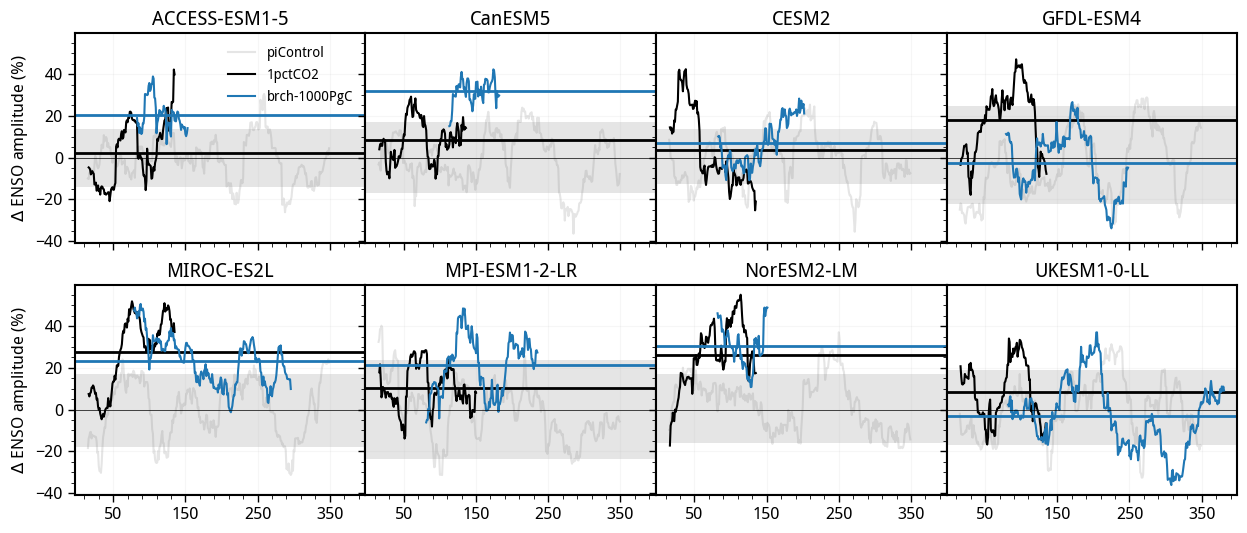

In [69]:
fig, axarr = plt.subplots(nrows=2, ncols=4, figsize=(15,6), constrained_layout=True, sharex=True, sharey=True)
axlist = axarr.flatten()
for i in range(len(axlist)):
    xdata0 = pic_dat[models_zec[i]].time.dt.year
    rolling_mag_pic = funcs.detrend_rolling_window(pic_dat[models_zec[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0).rolling(time = 30, center=True).std('time')
    pic_change = (rolling_mag_pic/rolling_mag_pic.mean('time') - 1)*100
    axlist[i].plot((xdata0 - xdata0[0])[1:350], pic_change.isel(time = slice(1, 350)), color='tab:gray', label='piControl', alpha=0.2)
    axlist[i].axhspan(pic_change.isel(time = slice(1, -1)).quantile(0.1, 'time'), pic_change.isel(time = slice(1, -1)).quantile(0.9, 'time'), color='tab:gray', alpha=0.2, lw=0.0)
    # bplot = axlist[i].boxplot(pic_change.dropna('time'), boxprops=dict(color='k'), meanline=False, widths=8, patch_artist=True, medianprops=dict(color='k'), showfliers=False, whis=[5, 95], positions=[-20])
    # for patch, color in zip(bplot['boxes'], ['k']):
        # patch.set_facecolor(color)

    # axlist[i].axhspan(nino34_pic.isel(time = slice(1, -1)).rolling(time=30, center=True).std('time').quantile(0.1, 'time'), nino34_pic.isel(time = slice(1, -1)).rolling(time=30, center=True).std('time').quantile(0.9, 'time'), color='tab:gray', alpha=0.3)
    #
    xdata0 = trans_dat[models_zec[i]].time.dt.year
    rolling_mag_trans = funcs.detrend_rolling_window(trans_dat[models_zec[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0).rolling(time = 30, center=True).std('time')
    trans_change = (rolling_mag_trans/rolling_mag_pic.mean('time') - 1)*100
    axlist[i].plot((xdata0 - xdata0[0])[1:-1], trans_change, color='k', label='1pctCO2')
    # axlist[i].plot([(xdata0 - xdata0[0])[30], (xdata0 - xdata0[0])[-30]], [trans_change.dropna('time')[1], trans_change.dropna('time')[-1]], color='k')
    axlist[i].axhline(trans_change.mean('time'), color='k', lw=2.0)
    # #
    xdata = stable1000_dat[models_zec[i]].time.dt.year
    rolling_mag_stable = funcs.detrend_rolling_window(stable1000_dat[models_zec[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0).rolling(time = 30, center=True).std('time')
    stable_change = (rolling_mag_stable/rolling_mag_pic.mean('time') - 1)*100
    axlist[i].plot((xdata - xdata0[0])[1:-1], stable_change, color='tab:blue', label='brch-1000PgC')
    # axlist[i].plot([(xdata - xdata0[0])[30], (xdata - xdata0[0])[-30]], [stable_change.dropna('time')[1], stable_change.dropna('time')[-1]], color='tab:blue')
    axlist[i].axhline(stable_change.mean('time'), color='tab:blue', lw=2.0)
    #
    axlist[i].set_xticks(np.arange(50, 450, 100))
    # axlist[i].set_xticklabels([str(x) for x in np.arange(50, 450, 100)])
    axlist[i].axhline(0.0, color='k', lw=0.5)
    # axlist[i].set_yticklabels([])
    # axlist[i].axhline(0.0, color='k', ls='-', lw=0.5)
    axlist[i].grid(alpha=0.1)
    # axlist[i].set_title(models_zec[i] + f' (n = {len(trans_dat[models_zec[i]].model)})', fontsize=14)
    axlist[i].set_title(models_zec[i], fontsize=14)

axlist[0].set_ylabel('$\Delta$ ENSO amplitude (%)')
axlist[4].set_ylabel('$\Delta$ ENSO amplitude (%)')
axlist[0].legend(frameon=False, loc='upper right', fontsize=10)

plt.subplots_adjust(wspace=0.0, hspace=0.2)
plt.minorticks_on()
# plt.ylim(0.5,3.5)
# sns.despine()

### ZECMIP warming levels

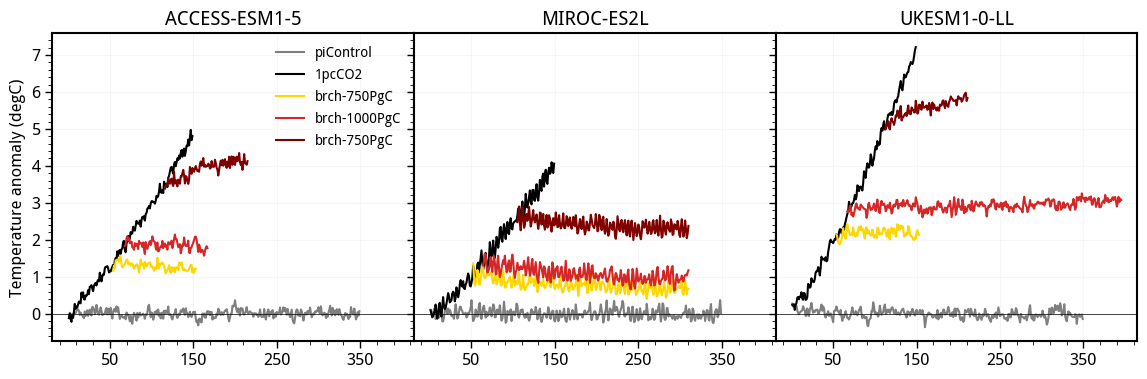

In [70]:
fig, axarr = plt.subplots(nrows=1, ncols=3, figsize=(14,4), constrained_layout=True, sharex=True, sharey=True)
axlist = axarr.flatten()
for i in range(len(axlist)):
    xdata0 = pic_dat[models_zec_warming_levels[i]].time.dt.year
    axlist[i].plot((xdata0 - xdata0[0])[1:350], pic_dat[models_zec_warming_levels[i]].weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, 350), model=0), color='tab:gray', label='piControl')
    #
    xdata0 = trans_dat[models_zec_warming_levels[i]].time.dt.year
    axlist[i].plot((xdata0 - xdata0[0])[1:-1], trans_dat[models_zec_warming_levels[i]].weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0), color='k', label='1pcCO2')
    #
    xdata = stable750_dat[models_zec_warming_levels[i]].time.dt.year
    axlist[i].plot((xdata - xdata0[0])[1:-1], np.squeeze(stable750_dat[models_zec_warming_levels[i]].weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1)).to_numpy()), color='gold', ls='-', label='brch-750PgC')
    #
    xdata = stable1000_dat[models_zec_warming_levels[i]].time.dt.year
    axlist[i].plot((xdata - xdata0[0])[1:-1], stable1000_dat[models_zec_warming_levels[i]].weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0), color='tab:red', ls='-', label='brch-1000PgC')
    #
    xdata = stable2000_dat[models_zec_warming_levels[i]].time.dt.year
    axlist[i].plot((xdata - xdata0[0])[1:-1], np.squeeze(stable2000_dat[models_zec_warming_levels[i]].weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1)).to_numpy()), color='maroon', ls='-', label='brch-750PgC')
    #
    axlist[i].set_xticks(np.arange(50, 450, 100))
    # axlist[i].set_yticklabels([])
    axlist[i].axhline(0.0, color='k', ls='-', lw=0.5)
    axlist[i].grid(alpha=0.1)
    # axlist[i].set_title(models_zec_warming_levels[i] + f' (n = {len(trans_dat[models_zec_warming_levels[i]].model)})', fontsize=14)
    axlist[i].set_title(models_zec_warming_levels[i], fontsize=14)

axlist[0].set_ylabel('Temperature anomaly (degC)')
# axlist[4].set_ylabel('Temperature anomaly (degC)')
axlist[0].legend(frameon=False, loc='upper right', fontsize=10)

plt.subplots_adjust(wspace=0.0, hspace=0.2)
plt.minorticks_on()
# sns.despine()

In [33]:
zec_values_temporal = np.empty((len(models_zec_warming_levels), 350))
zec_values_temporal[:] = np.nan
for i in range(len(zec_values_temporal)):
    branching_time = int(stable750_dat[models_zec_warming_levels[i]].time[0].dt.year)
    if branching_time > 100 and branching_time < 1000:
        start_time = '0'+str(branching_time - 15)
        end_time = '0'+str(branching_time + 15)
    elif branching_time < 100:
        start_time = '00'+str(branching_time - 15)
        end_time = '00'+str(branching_time + 15)
    else:
        start_time = str(branching_time - 15)
        end_time = str(branching_time + 15)
    base = trans_dat[models_zec_warming_levels[i]].sel(time = slice(start_time, end_time)).weighted(weights).mean(('time', 'lat', 'lon')).isel(model=0)
    xdata0 = trans_dat[models_zec_warming_levels[i]].time.dt.year
    xdata = stable750_dat[models_zec_warming_levels[i]].time.dt.year
    zec_values_temporal[i, 0:len(xdata)-2] = stable750_dat[models_zec_warming_levels[i]].weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0) - base
    # plt.plot((xdata - xdata0[i])[1:-1], zec_values_temporal, color='k', ls='-', label='1000PgC Branching', alpha=0.2)
    # # plt.set_xticks(np.arange(50, 450, 100))
    # # plt.set_yticklabels([])
    # # plt.axhline(0.0, color='k', ls='-', lw=0.5)
    # plt.grid(alpha=0.1)
    # # plt.set_title(models_zec_warming_levels[i] + f' (n = {len(trans_dat[models_zec_warming_levels[i]].model)})', fontsize=14)
    # plt.set_title(models_zec_warming_levels[i], fontsize=14)

# axlist[0].set_ylabel('Temperature anomaly (degC)')
# axlist[4].set_ylabel('Temperature anomaly (degC)')
# axlist[0].legend(frameon=False, loc='upper right', fontsize=10)

# plt.subplots_adjust(wspace=0.0, hspace=0.2)
# plt.minorticks_on()
# sns.despine()

Text(0.5, 1.0, 'brch-750PgC ZEC')

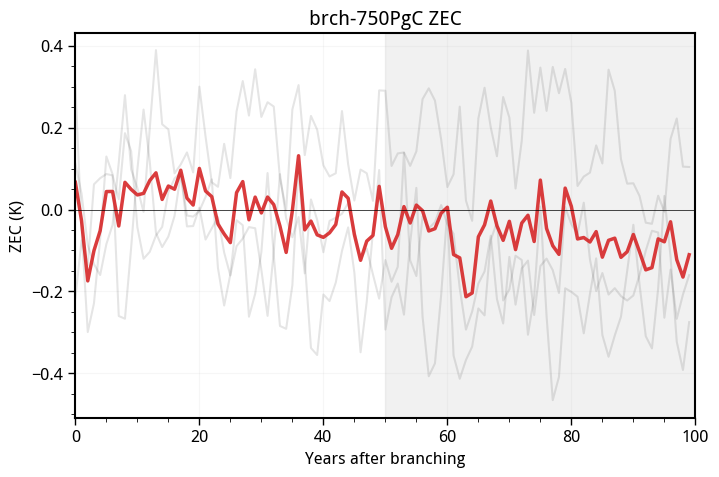

In [45]:
plt.figure(figsize=(8, 5))
for i in range(len(models_zec_warming_levels)):
    plt.plot(zec_values_temporal[i][:100], color='k', alpha=0.1)
plt.plot(np.nanmean(zec_values_temporal, axis=0)[:100], color='tab:red', alpha=0.9, lw=2.5)
# plt.set_yticklabels([])
plt.axhline(0.0, color='k', ls='-', lw=0.5)
plt.grid(alpha=0.1)
plt.minorticks_on()
plt.xlabel('Years after branching')
plt.ylabel('ZEC (K)')
plt.xlim(0, 100)
# plt.axvspan(10, 40, color='tab:blue', alpha=0.1)
# plt.axvspan(35, 65, color='tab:green', alpha=0.1)
# plt.axvspan(75, 105, color='tab:purple', alpha=0.1)
# plt.axvspan(105, 135, color='tab:red', alpha=0.1)
plt.axvspan(50, 100, color='tab:gray', alpha=0.1)
plt.title('brch-750PgC ZEC')

In [47]:
zec_values_temporal = np.empty((len(models_zec_warming_levels), 350))
zec_values_temporal[:] = np.nan
for i in range(len(zec_values_temporal)):
    branching_time = int(stable2000_dat[models_zec_warming_levels[i]].time[0].dt.year)
    if branching_time > 100 and branching_time < 1000:
        start_time = '0'+str(branching_time - 15)
        end_time = '0'+str(branching_time + 15)
    elif branching_time < 100:
        start_time = '00'+str(branching_time - 15)
        end_time = '00'+str(branching_time + 15)
    else:
        start_time = str(branching_time - 15)
        end_time = str(branching_time + 15)
    base = trans_dat[models_zec_warming_levels[i]].sel(time = slice(start_time, end_time)).weighted(weights).mean(('time', 'lat', 'lon')).isel(model=0)
    xdata0 = trans_dat[models_zec_warming_levels[i]].time.dt.year
    xdata = stable2000_dat[models_zec_warming_levels[i]].time.dt.year
    zec_values_temporal[i, 0:len(xdata)-2] = stable2000_dat[models_zec_warming_levels[i]].weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0) - base
    # plt.plot((xdata - xdata0[i])[1:-1], zec_values_temporal, color='k', ls='-', label='1000PgC Branching', alpha=0.2)
    # # plt.set_xticks(np.arange(50, 450, 100))
    # # plt.set_yticklabels([])
    # # plt.axhline(0.0, color='k', ls='-', lw=0.5)
    # plt.grid(alpha=0.1)
    # # plt.set_title(models_zec_warming_levels[i] + f' (n = {len(trans_dat[models_zec_warming_levels[i]].model)})', fontsize=14)
    # plt.set_title(models_zec_warming_levels[i], fontsize=14)

# axlist[0].set_ylabel('Temperature anomaly (degC)')
# axlist[4].set_ylabel('Temperature anomaly (degC)')
# axlist[0].legend(frameon=False, loc='upper right', fontsize=10)

# plt.subplots_adjust(wspace=0.0, hspace=0.2)
# plt.minorticks_on()
# sns.despine()

Text(0.5, 1.0, 'brch-2000PgC ZEC')

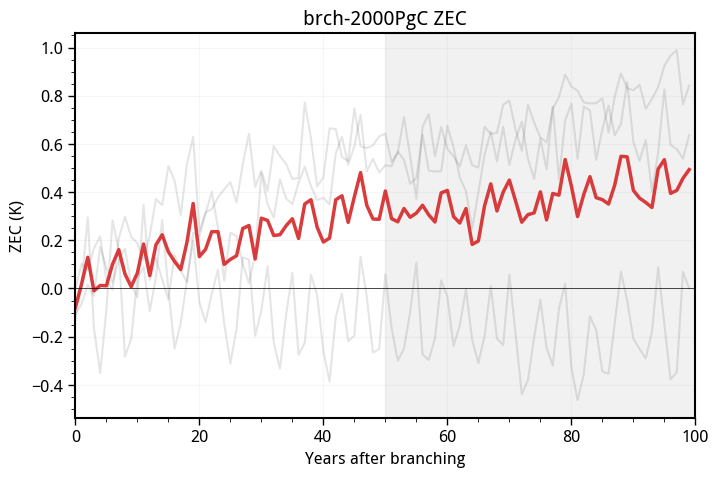

In [49]:
plt.figure(figsize=(8, 5))
for i in range(len(models_zec_warming_levels)):
    plt.plot(zec_values_temporal[i][:100], color='k', alpha=0.1)
plt.plot(np.nanmean(zec_values_temporal, axis=0)[:100], color='tab:red', alpha=0.9, lw=2.5)
# plt.set_yticklabels([])
plt.axhline(0.0, color='k', ls='-', lw=0.5)
plt.grid(alpha=0.1)
plt.minorticks_on()
plt.xlabel('Years after branching')
plt.ylabel('ZEC (K)')
plt.xlim(0, 100)
# plt.axvspan(10, 40, color='tab:blue', alpha=0.1)
# plt.axvspan(35, 65, color='tab:green', alpha=0.1)
# plt.axvspan(75, 105, color='tab:purple', alpha=0.1)
# plt.axvspan(105, 135, color='tab:red', alpha=0.1)
plt.axvspan(50, 100, color='tab:gray', alpha=0.1)
plt.title('brch-2000PgC ZEC')

In [34]:
# zec25_changes = []
# zec50_changes = []
# zec90_changes = []
# zec120_changes = []
zec_changes = []


for m in range(len(models_zec_warming_levels)):
    branching_time = int(stable750_dat[models_zec_warming_levels[m]].time[0].dt.year)
    if branching_time > 100 and branching_time < 1000:
        start_time = '0'+str(branching_time - 15)
        end_time = '0'+str(branching_time + 15)
    elif branching_time < 100:
        start_time = '00'+str(branching_time - 15)
        end_time = '00'+str(branching_time + 15)
    else:
        start_time = str(branching_time - 15)
        end_time = str(branching_time + 15)
    base = trans_dat[models_zec_warming_levels[m]].sel(time = slice(start_time, end_time)).mean(('time', 'model'))

    # post25 = stable750_dat[models_zec_warming_levels[m]].isel(time = slice(10, 40)).mean(('time', 'model'))
    # post50 = stable750_dat[models_zec_warming_levels[m]].isel(time = slice(35, 65)).mean(('time', 'model'))
    # post90 = stable750_dat[models_zec_warming_levels[m]].isel(time = slice(75, 105)).mean(('time', 'model'))
    # post120 = stable750_dat[models_zec_warming_levels[m]].isel(time = slice(105, 135)).mean(('time', 'model'))
    post = stable750_dat[models_zec_warming_levels[m]].isel(time = slice(50, 100)).mean(('time', 'model'))

    # zec25_changes.append((post25 - base))
    # zec50_changes.append((post50 - base))
    # zec90_changes.append((post90 - base))
    # zec120_changes.append((post120 - base))
    zec_changes.append((post - base))
    print(f'Completed {m+1}')

Completed 1
Completed 2
Completed 3


In [35]:
xx, yy = np.meshgrid(zec_changes[0].lon, zec_changes[0].lat)

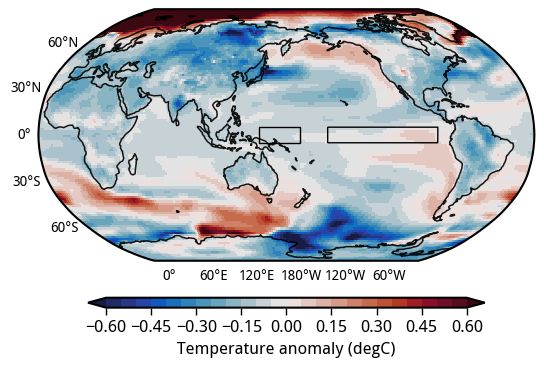

In [36]:
# plt.figure(figsize=(6,7))
ax = plt.axes(projection=ccrs.Robinson(central_longitude=160))
# ax.set_aspect('auto')
xr.concat(zec_changes, dim=models_zec_warming_levels).mean('concat_dim').plot.pcolormesh(transform=ccrs.PlateCarree(), cmap=cmocean.cm.balance, levels=np.arange(-0.6, 0.65, 0.05), cbar_kwargs=dict(orientation='horizontal', shrink=0.8, aspect=40, pad=0.1, label='Temperature anomaly (degC)'))
plot_background(ax)
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                            facecolor='none', edgecolor='k',
                            transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                            facecolor='none', edgecolor='k',
                            transform=ccrs.PlateCarree()))
# axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
#                                 facecolor='none', edgecolor='k',
#                                 transform=ccrs.PlateCarree()))
# axlist[i].add_patch(mpatches.Rectangle(xy=[140, 60], width=150, height=20,
#                                             facecolor='none', edgecolor='tab:green', lw=1.5,
#                                             transform=ccrs.PlateCarree()))
# axlist[i].add_patch(mpatches.Rectangle(xy=[140, -80], width=150, height=20,
#                                             facecolor='none', edgecolor='tab:green', lw=1.5,
#                                             transform=ccrs.PlateCarree()))
# axlist[i].add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
#                                             facecolor='none', edgecolor='k', lw=1.5,
#                                             transform=ccrs.PlateCarree()))
# axlist[i].add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
#                                             facecolor='none', edgecolor='k', lw=1.5,
#                                             transform=ccrs.PlateCarree()))

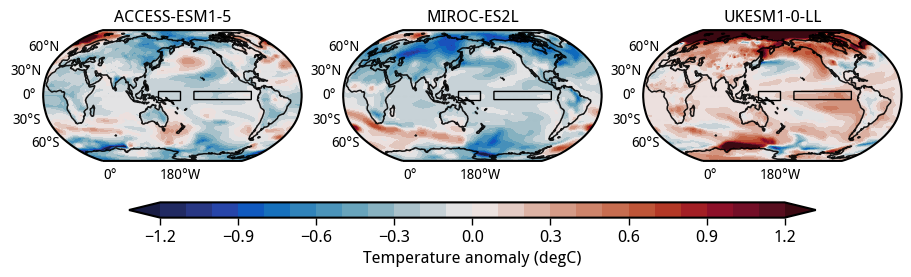

In [37]:
plot_maps(xx, yy, zec_changes, titles=models_zec_warming_levels, labels=['']*8, cmap=cmocean.cm.balance, levels=np.arange(-1.2, 1.3, 0.1), cbar_label = 'Temperature anomaly (degC)', nrows=1, ncols=3, figsize=(9,4.5), land_mask_list = [], add_patch=True, add_patch_extra=False, cbar_orientation='horizontal', hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160))

In [44]:
# zec25_changes = []
# zec50_changes = []
# zec90_changes = []
# zec120_changes = []
zec_changes = []


for m in range(len(models_zec_warming_levels)):
    branching_time = int(stable1000_dat[models_zec_warming_levels[m]].time[0].dt.year)
    if branching_time > 100 and branching_time < 1000:
        start_time = '0'+str(branching_time - 15)
        end_time = '0'+str(branching_time + 15)
    elif branching_time < 100:
        start_time = '00'+str(branching_time - 15)
        end_time = '00'+str(branching_time + 15)
    else:
        start_time = str(branching_time - 15)
        end_time = str(branching_time + 15)
    base = trans_dat[models_zec_warming_levels[m]].sel(time = slice(start_time, end_time)).mean(('time', 'model'))

    # post25 = stable1000_dat[models_zec_warming_levels[m]].isel(time = slice(10, 40)).mean(('time', 'model'))
    # post50 = stable1000_dat[models_zec_warming_levels[m]].isel(time = slice(35, 65)).mean(('time', 'model'))
    # post90 = stable1000_dat[models_zec_warming_levels[m]].isel(time = slice(75, 105)).mean(('time', 'model'))
    # post120 = stable1000_dat[models_zec_warming_levels[m]].isel(time = slice(105, 135)).mean(('time', 'model'))
    post = stable1000_dat[models_zec_warming_levels[m]].isel(time = slice(50, 100)).mean(('time', 'model'))

    # zec25_changes.append((post25 - base))
    # zec50_changes.append((post50 - base))
    # zec90_changes.append((post90 - base))
    # zec120_changes.append((post120 - base))
    zec_changes.append((post - base))
    print(f'Completed {m+1}')

Completed 1
Completed 2
Completed 3


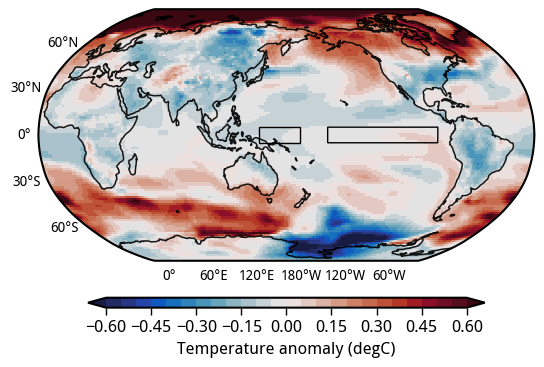

In [45]:
# plt.figure(figsize=(6,7))
ax = plt.axes(projection=ccrs.Robinson(central_longitude=160))
# ax.set_aspect('auto')
xr.concat(zec_changes, dim=models_zec_warming_levels).mean('concat_dim').plot.pcolormesh(transform=ccrs.PlateCarree(), cmap=cmocean.cm.balance, levels=np.arange(-0.6, 0.65, 0.05), cbar_kwargs=dict(orientation='horizontal', shrink=0.8, aspect=40, pad=0.1, label='Temperature anomaly (degC)'))
plot_background(ax)
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                            facecolor='none', edgecolor='k',
                            transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                            facecolor='none', edgecolor='k',
                            transform=ccrs.PlateCarree()))
# axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
#                                 facecolor='none', edgecolor='k',
#                                 transform=ccrs.PlateCarree()))
# axlist[i].add_patch(mpatches.Rectangle(xy=[140, 60], width=150, height=20,
#                                             facecolor='none', edgecolor='tab:green', lw=1.5,
#                                             transform=ccrs.PlateCarree()))
# axlist[i].add_patch(mpatches.Rectangle(xy=[140, -80], width=150, height=20,
#                                             facecolor='none', edgecolor='tab:green', lw=1.5,
#                                             transform=ccrs.PlateCarree()))
# axlist[i].add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
#                                             facecolor='none', edgecolor='k', lw=1.5,
#                                             transform=ccrs.PlateCarree()))
# axlist[i].add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
#                                             facecolor='none', edgecolor='k', lw=1.5,
#                                             transform=ccrs.PlateCarree()))

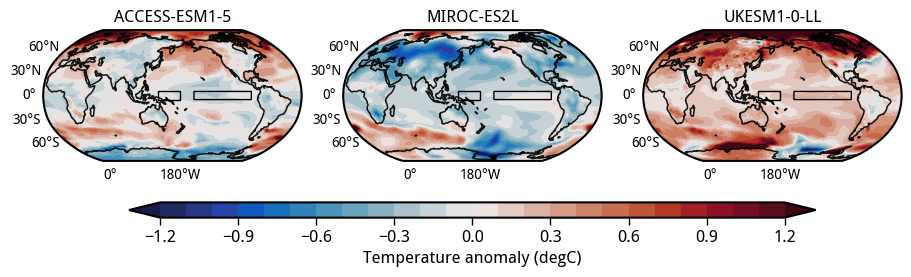

In [39]:
plot_maps(xx, yy, zec_changes, titles=models_zec_warming_levels, labels=['']*8, cmap=cmocean.cm.balance, levels=np.arange(-1.2, 1.3, 0.1), cbar_label = 'Temperature anomaly (degC)', nrows=1, ncols=3, figsize=(9,4.5), land_mask_list = [], add_patch=True, add_patch_extra=False, cbar_orientation='horizontal', hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160))

In [40]:
# zec25_changes = []
# zec50_changes = []
# zec90_changes = []
# zec120_changes = []
zec_changes = []


for m in range(len(models_zec_warming_levels)):
    branching_time = int(stable2000_dat[models_zec_warming_levels[m]].time[0].dt.year)
    if branching_time > 100 and branching_time < 1000:
        start_time = '0'+str(branching_time - 15)
        end_time = '0'+str(branching_time + 15)
    elif branching_time < 100:
        start_time = '00'+str(branching_time - 15)
        end_time = '00'+str(branching_time + 15)
    else:
        start_time = str(branching_time - 15)
        end_time = str(branching_time + 15)
    base = trans_dat[models_zec_warming_levels[m]].sel(time = slice(start_time, end_time)).mean(('time', 'model'))

    # post25 = stable2000_dat[models_zec_warming_levels[m]].isel(time = slice(10, 40)).mean(('time', 'model'))
    # post50 = stable2000_dat[models_zec_warming_levels[m]].isel(time = slice(35, 65)).mean(('time', 'model'))
    # post90 = stable2000_dat[models_zec_warming_levels[m]].isel(time = slice(75, 105)).mean(('time', 'model'))
    # post120 = stable2000_dat[models_zec_warming_levels[m]].isel(time = slice(105, 135)).mean(('time', 'model'))
    post = stable2000_dat[models_zec_warming_levels[m]].isel(time = slice(50, 100)).mean(('time', 'model'))

    # zec25_changes.append((post25 - base))
    # zec50_changes.append((post50 - base))
    # zec90_changes.append((post90 - base))
    # zec120_changes.append((post120 - base))
    zec_changes.append((post - base))
    print(f'Completed {m+1}')

Completed 1
Completed 2
Completed 3


In [41]:
xx, yy = np.meshgrid(zec_changes[0].lon, zec_changes[0].lat)

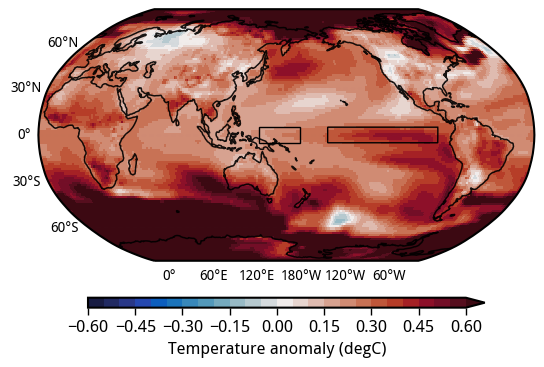

In [42]:
# plt.figure(figsize=(6,7))
ax = plt.axes(projection=ccrs.Robinson(central_longitude=160))
# ax.set_aspect('auto')
xr.concat(zec_changes, dim=models_zec_warming_levels).mean('concat_dim').plot.pcolormesh(transform=ccrs.PlateCarree(), cmap=cmocean.cm.balance, levels=np.arange(-0.6, 0.65, 0.05), cbar_kwargs=dict(orientation='horizontal', shrink=0.8, aspect=40, pad=0.1, label='Temperature anomaly (degC)'))
plot_background(ax)
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                            facecolor='none', edgecolor='k',
                            transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                            facecolor='none', edgecolor='k',
                            transform=ccrs.PlateCarree()))
# axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
#                                 facecolor='none', edgecolor='k',
#                                 transform=ccrs.PlateCarree()))
# axlist[i].add_patch(mpatches.Rectangle(xy=[140, 60], width=150, height=20,
#                                             facecolor='none', edgecolor='tab:green', lw=1.5,
#                                             transform=ccrs.PlateCarree()))
# axlist[i].add_patch(mpatches.Rectangle(xy=[140, -80], width=150, height=20,
#                                             facecolor='none', edgecolor='tab:green', lw=1.5,
#                                             transform=ccrs.PlateCarree()))
# axlist[i].add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
#                                             facecolor='none', edgecolor='k', lw=1.5,
#                                             transform=ccrs.PlateCarree()))
# axlist[i].add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
#                                             facecolor='none', edgecolor='k', lw=1.5,
#                                             transform=ccrs.PlateCarree()))

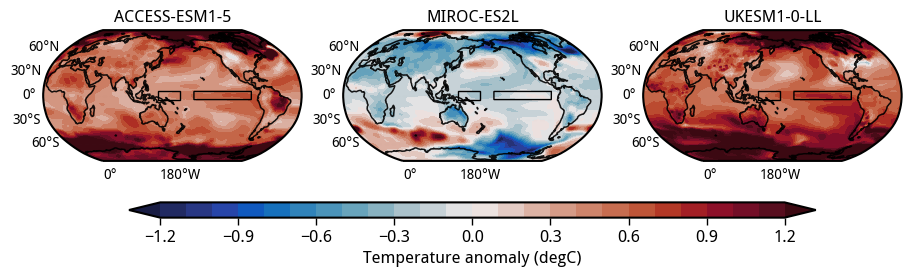

In [43]:
plot_maps(xx, yy, zec_changes, titles=models_zec_warming_levels, labels=['']*8, cmap=cmocean.cm.balance, levels=np.arange(-1.2, 1.3, 0.1), cbar_label = 'Temperature anomaly (degC)', nrows=1, ncols=3, figsize=(9,4.5), land_mask_list = [], add_patch=True, add_patch_extra=False, cbar_orientation='horizontal', hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160))

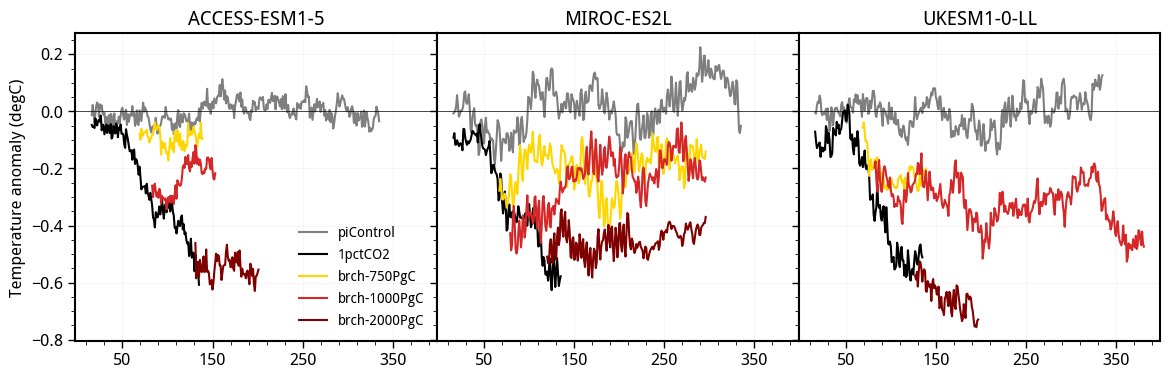

In [76]:
fig, axarr = plt.subplots(nrows=1, ncols=3, figsize=(14,4), constrained_layout=True, sharex=True, sharey=True)
axlist = axarr.flatten()
for i in range(len(axlist)):
    xdata0 = pic_dat[models_zec_warming_levels[i]].time.dt.year
    sst_grad_pic = pic_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0) - pic_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0)
    axlist[i].plot((xdata0 - xdata0[0])[1:350], sst_grad_pic.isel(time = slice(1, 350)).rolling(time=30, center=True).mean('time'), color='tab:gray', label='piControl')
    #
    xdata0 = trans_dat[models_zec_warming_levels[i]].time.dt.year
    sst_grad_trans = trans_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0) - trans_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0)
    axlist[i].plot((xdata0 - xdata0[0])[1:-1], sst_grad_trans.rolling(time=30, center=True).mean('time'), color='k', label='1pctCO2')
    #
    xdata = stable750_dat[models_zec_warming_levels[i]].time.dt.year
    sst_grad_stable = stable750_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0) - stable750_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0)
    axlist[i].plot((xdata - xdata0[0])[1:-1], sst_grad_stable.rolling(time=30, center=True).mean('time'), color='gold', ls='-', label='brch-750PgC')
    #
    xdata = stable1000_dat[models_zec_warming_levels[i]].time.dt.year
    sst_grad_stable = stable1000_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0) - stable1000_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0)
    axlist[i].plot((xdata - xdata0[0])[1:-1], sst_grad_stable.rolling(time=30, center=True).mean('time'), color='tab:red', ls='-', label='brch-1000PgC')
    #
    xdata = stable2000_dat[models_zec_warming_levels[i]].time.dt.year
    sst_grad_stable = stable2000_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0) - stable2000_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0)
    axlist[i].plot((xdata - xdata0[0])[1:-1], sst_grad_stable.rolling(time=30, center=True).mean('time'), color='maroon', ls='-', label='brch-2000PgC')
    #
    axlist[i].set_xticks(np.arange(50, 450, 100))
    # axlist[i].set_yticklabels([])
    axlist[i].axhline(0.0, color='k', ls='-', lw=0.5)
    axlist[i].grid(alpha=0.1)
    # axlist[i].set_title(models_zec_warming_levels[i] + f' (n = {len(trans_dat[models_zec_warming_levels[i]].model)})', fontsize=14)
    axlist[i].set_title(models_zec_warming_levels[i], fontsize=14)

axlist[0].set_ylabel('Temperature anomaly (degC)')
# axlist[4].set_ylabel('Temperature anomaly (degC)')
axlist[0].legend(frameon=False, loc='lower right', fontsize=10)

plt.subplots_adjust(wspace=0.0, hspace=0.2)
plt.minorticks_on()
# plt.ylim(0.5,3.5)
# sns.despine()

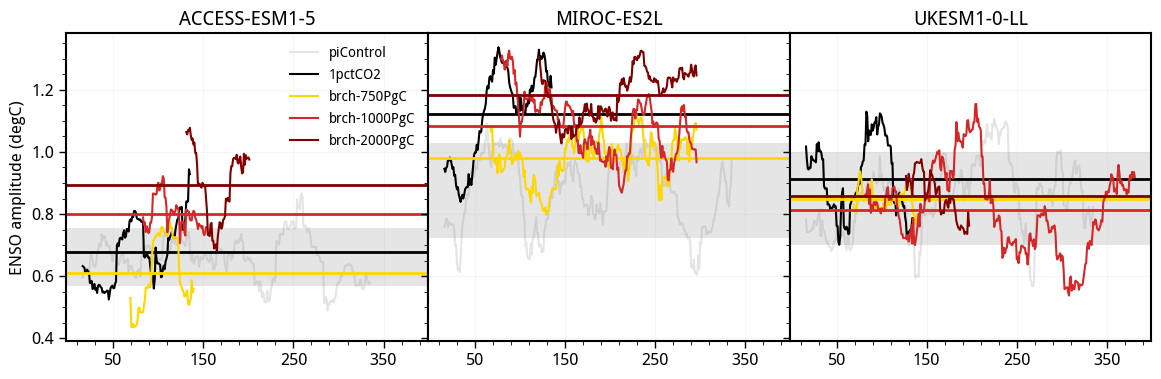

In [74]:
fig, axarr = plt.subplots(nrows=1, ncols=3, figsize=(14,4), constrained_layout=True, sharex=True, sharey=True)
axlist = axarr.flatten()
for i in range(len(axlist)):
    xdata0 = pic_dat[models_zec_warming_levels[i]].time.dt.year
    nino34_pic = funcs.detrend_rolling_window(pic_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0)
    axlist[i].plot((xdata0 - xdata0[0])[1:350], nino34_pic.isel(time = slice(1, 350)).rolling(time=30, center=True).std('time'), color='tab:gray', alpha=0.2, label='piControl')
    # axlist[i].axhline(nino34_pic.rolling(time=30, center=True).std('time').mean('time'), color='k', lw=2.0)
    # axlist[i].axhline(nino34_pic.rolling(time=30, center=True).std('time').mean('time'), color='k', lw=2.0)
    axlist[i].axhspan(nino34_pic.rolling(time=30, center=True).std('time').quantile(0.1, 'time'), nino34_pic.rolling(time=30, center=True).std('time').quantile(0.9, 'time'), color='tab:gray', alpha=0.2, lw=0.0)
    #
    xdata0 = trans_dat[models_zec_warming_levels[i]].time.dt.year
    nino34_trans = funcs.detrend_rolling_window(trans_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0)
    axlist[i].plot((xdata0 - xdata0[0])[1:-1], nino34_trans.rolling(time=30, center=True).std('time'), color='k', label='1pctCO2')
    axlist[i].axhline(nino34_trans.rolling(time=30, center=True).std('time').mean('time'), color='k', lw=2.0)
    #
    xdata = stable750_dat[models_zec_warming_levels[i]].time.dt.year
    nino34_stable = funcs.detrend_rolling_window(stable750_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0)
    axlist[i].plot((xdata - xdata0[0])[1:-1], nino34_stable.rolling(time=30, center=True).std('time'), color='gold', ls='-', label='brch-750PgC')
    axlist[i].axhline(nino34_stable.rolling(time=30, center=True).std('time').mean('time'), color='gold', ls='-', lw=2.0)
    #
    xdata = stable1000_dat[models_zec_warming_levels[i]].time.dt.year
    nino34_stable = funcs.detrend_rolling_window(stable1000_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0)
    axlist[i].plot((xdata - xdata0[0])[1:-1], nino34_stable.rolling(time=30, center=True).std('time'), color='tab:red', ls='-', label='brch-1000PgC')
    axlist[i].axhline(nino34_stable.rolling(time=30, center=True).std('time').mean('time'), color='tab:red', ls='-', lw=2.0)
    #
    xdata = stable2000_dat[models_zec_warming_levels[i]].time.dt.year
    nino34_stable = funcs.detrend_rolling_window(stable2000_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0)
    axlist[i].plot((xdata - xdata0[0])[1:-1], nino34_stable.rolling(time=30, center=True).std('time'), color='maroon', ls='-', label='brch-2000PgC')
    axlist[i].axhline(nino34_stable.rolling(time=30, center=True).std('time').mean('time'), color='maroon', ls='-', lw=2.0)
    #
    axlist[i].set_xticks(np.arange(50, 450, 100))
    # axlist[i].set_yticklabels([])
    # axlist[i].axhline(0.0, color='k', ls='-', lw=0.5)
    axlist[i].grid(alpha=0.1)
    # axlist[i].set_title(models_zec_warming_levels[i] + f' (n = {len(trans_dat[models_zec_warming_levels[i]].model)})', fontsize=14)
    axlist[i].set_title(models_zec_warming_levels[i], fontsize=14)

axlist[0].set_ylabel('ENSO amplitude (degC)')
# axlist[4].set_ylabel('Temperature anomaly (degC)')
axlist[0].legend(frameon=False, loc='upper right', fontsize=10)

plt.subplots_adjust(wspace=0.0, hspace=0.2)
plt.minorticks_on()
# plt.ylim(0.5,3.5)
# sns.despine()

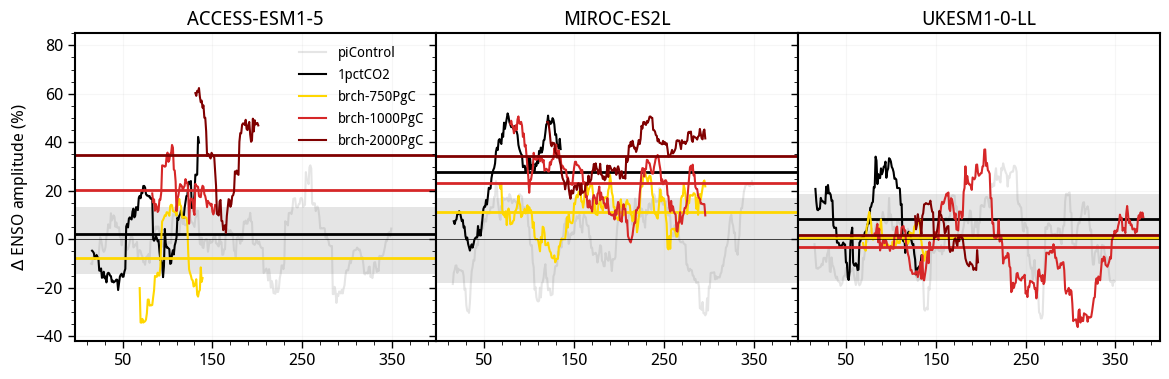

In [73]:
fig, axarr = plt.subplots(nrows=1, ncols=3, figsize=(14,4), constrained_layout=True, sharex=True, sharey=True)
axlist = axarr.flatten()
for i in range(len(axlist)):
    xdata0 = pic_dat[models_zec_warming_levels[i]].time.dt.year
    rolling_mag_pic = funcs.detrend_rolling_window(pic_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0).rolling(time = 30, center=True).std('time')
    pic_change = (rolling_mag_pic/rolling_mag_pic.mean('time') - 1)*100
    axlist[i].plot((xdata0 - xdata0[0])[1:350], pic_change.isel(time = slice(1, 350)), color='tab:gray', label='piControl', alpha=0.2)
    axlist[i].axhspan(pic_change.isel(time = slice(1, -1)).quantile(0.1, 'time'), pic_change.isel(time = slice(1, -1)).quantile(0.9, 'time'), color='tab:gray', alpha=0.2, lw=0.0)
    # bplot = axlist[i].boxplot(pic_change.dropna('time'), boxprops=dict(color='k'), meanline=False, widths=8, patch_artist=True, medianprops=dict(color='k'), showfliers=False, whis=[5, 95], positions=[-20])
    # for patch, color in zip(bplot['boxes'], ['k']):
        # patch.set_facecolor(color)

    # axlist[i].axhspan(nino34_pic.isel(time = slice(1, -1)).rolling(time=30, center=True).std('time').quantile(0.1, 'time'), nino34_pic.isel(time = slice(1, -1)).rolling(time=30, center=True).std('time').quantile(0.9, 'time'), color='tab:gray', alpha=0.3)
    #
    xdata0 = trans_dat[models_zec_warming_levels[i]].time.dt.year
    rolling_mag_trans = funcs.detrend_rolling_window(trans_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0).rolling(time = 30, center=True).std('time')
    trans_change = (rolling_mag_trans/rolling_mag_pic.mean('time') - 1)*100
    axlist[i].plot((xdata0 - xdata0[0])[1:-1], trans_change, color='k', label='1pctCO2')
    axlist[i].axhline(trans_change.mean('time'), color='k', lw=2.0)
    # #
    xdata = stable750_dat[models_zec_warming_levels[i]].time.dt.year
    rolling_mag_stable = funcs.detrend_rolling_window(stable750_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0).rolling(time = 30, center=True).std('time')
    stable_change = (rolling_mag_stable/rolling_mag_pic.mean('time') - 1)*100
    axlist[i].plot((xdata - xdata0[0])[1:-1], stable_change, color='gold', label='brch-750PgC')
    axlist[i].axhline(stable_change.mean('time'), color='gold', lw=2.0)
    #
    xdata = stable1000_dat[models_zec_warming_levels[i]].time.dt.year
    rolling_mag_stable = funcs.detrend_rolling_window(stable1000_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0).rolling(time = 30, center=True).std('time')
    stable_change = (rolling_mag_stable/rolling_mag_pic.mean('time') - 1)*100
    axlist[i].plot((xdata - xdata0[0])[1:-1], stable_change, color='tab:red', label='brch-1000PgC')
    axlist[i].axhline(stable_change.mean('time'), color='tab:red', lw=2.0)
    #
    xdata = stable2000_dat[models_zec_warming_levels[i]].time.dt.year
    rolling_mag_stable = funcs.detrend_rolling_window(stable2000_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0).rolling(time = 30, center=True).std('time')
    stable_change = (rolling_mag_stable/rolling_mag_pic.mean('time') - 1)*100
    axlist[i].plot((xdata - xdata0[0])[1:-1], stable_change, color='maroon', label='brch-2000PgC')
    axlist[i].axhline(stable_change.mean('time'), color='maroon', lw=2.0)
    #
    axlist[i].set_xticks(np.arange(50, 450, 100))
    axlist[i].set_ylim(-42, 85)
    # axlist[i].set_xticklabels([str(x) for x in np.arange(50, 450, 100)])
    axlist[i].axhline(0.0, color='k', lw=0.5)
    # axlist[i].set_yticklabels([])
    # axlist[i].axhline(0.0, color='k', ls='-', lw=0.5)
    axlist[i].grid(alpha=0.1)
    # axlist[i].set_title(models_zec_warming_levels[i] + f' (n = {len(trans_dat[models_zec_warming_levels[i]].model)})', fontsize=14)
    axlist[i].set_title(models_zec_warming_levels[i], fontsize=14)

axlist[0].set_ylabel('$\Delta$ ENSO amplitude (%)')
# axlist[4].set_ylabel('$\Delta$ ENSO variability (%)')
axlist[0].legend(frameon=False, loc='upper right', fontsize=10)

plt.subplots_adjust(wspace=0.0, hspace=0.2)
plt.minorticks_on()
# plt.ylim(0.5,3.5)
# sns.despine()